In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tangermeme.plot import plot_logo
from tangermeme.io import read_meme
from tangermeme.utils import one_hot_encode, characters
import pyBigWig
from scipy.stats import pearsonr, spearmanr, levene, brunnermunzel
from scipy import stats

from tqdm import tqdm
import seaborn as sns


## 1. Loading

In [3]:
id = 2
epi = 'H3K27ac'

### 1.1 Loading perturb scores and the corresponding sequences.

In [4]:
seq = np.load('../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human_inter/GM12878/seq_9.npy')
print(seq.shape)

(1, 4, 138394717)


In [5]:
attr_files = {
    'GM12878' : f'../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human_inter/GM12878/{epi}/attr_9_filled.npy', 
    'H1ESC'    : f'../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human_inter/H1ESC/{epi}/attr_9_filled.npy',
    'K562'    : f'../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human_inter/K562/{epi}/attr_9_filled.npy',
}

In [6]:
def standardize(v):
    score = np.sum(v, axis=0)
    std = np.std(score)
    print(std)
    normalized = v / std
    return normalized

def quantile(v, l=20, q=0.999):
    score = np.sum(v, axis=0)
    c = np.cumsum(score)
    s = (c[l:]-c[:-l])/l
    return np.quantile(np.abs(s), q)

attrs_raw = {}
attrs_standardized = {}
thres = {}
for k, v in attr_files.items():
    attrs_raw[k] = np.load(v)[0]
    print(k)
    print(attrs_raw[k].shape)
    print(np.max(attrs_raw[k]))
    print(np.min(attrs_raw[k]))
    attrs_standardized[k] = standardize(attrs_raw[k])
    print(np.max(attrs_standardized[k]))
    print(np.min(attrs_standardized[k]))
    thres[k] = quantile(attrs_standardized[k])
    print(thres[k])



GM12878
(4, 133797422)
0.00025468438980169594
-0.0006633202572218635
6.415522562072257e-07
396.9815199581048
-1033.930207249722
6.108770579474541
H1ESC
(4, 133797422)
3.6175384593661875e-05
-7.243648724397644e-05
1.5605750952981156e-07
231.80803476010433
-464.1653417526758
5.684470303690391
K562
(4, 133797422)
0.0001325813209405169
-0.00036808388540521264
3.1447339092752866e-07
421.59789910832444
-1170.4770451947036
6.677514033022305


### 1.2 Loading motif data

In [7]:
all_hits = pd.read_csv('../data/dna/human/chr9_motif_match.bed', sep='\t', header=None)
# all_hits.columns = ['chromosome', 'start', 'end', 'archetype_name', 'motif_score', 'strand', 'motif_name', 'seq']
all_hits.columns = ['chromosome', 'start', 'end', 'motif_name', 'motif_score', 'strand', 'seq']

In [8]:
cols = list(all_hits.columns)
cols = cols[3:4]+cols[:3]+cols[4:]
all_hits = all_hits[cols]


In [9]:
all_hits

,motif_name,chromosome,start,end,motif_score,strand,seq
0,RREB1_MA0073.1,chr9,10003,10023,3.753597,+,CCCTAACCCTAACCCTAACC
1,RREB1_MA0073.1,chr9,10009,10029,5.226005,+,CCCTAACCCTAACCCAACCC
2,SP5_MOUSE.H11MO.0.C,chr9,10009,10033,8.217966,-,CCCTAACCCTAACCCAACCCCACC
3,RARA+RXRG_MA1149.1,chr9,10012,10030,8.263471,-,TAACCCTAACCCAACCCC
4,ZN467_HUMAN.H11MO.0.C,chr9,10013,10035,5.257850,-,AACCCTAACCCAACCCCACCCC
...,...,...,...,...,...,...,...
95646399,NKX32_HUMAN.H11MO.0.C,chr9,138334697,138334707,8.296515,+,CTAAGTGTTT
95646400,NKX32_MOUSE.H11MO.0.B,chr9,138334697,138334707,8.296515,+,CTAAGTGTTT
95646401,FOXJ2_HUMAN.H11MO.0.C,chr9,138334702,138334712,8.234549,+,TGTTTGTTGG
95646402,FOXJ2_MOUSE.H11MO.0.C,chr9,138334702,138334712,8.234549,+,TGTTTGTTGG


In [10]:
jaspar_hits = all_hits[all_hits['motif_name'].str.contains('_MA')]
jaspar_hits = jaspar_hits[~jaspar_hits['motif_name'].str.contains('_MADS')]

In [11]:
jaspar_hits

,motif_name,chromosome,start,end,motif_score,strand,seq
0,RREB1_MA0073.1,chr9,10003,10023,3.753597,+,CCCTAACCCTAACCCTAACC
1,RREB1_MA0073.1,chr9,10009,10029,5.226005,+,CCCTAACCCTAACCCAACCC
3,RARA+RXRG_MA1149.1,chr9,10012,10030,8.263471,-,TAACCCTAACCCAACCCC
5,RREB1_MA0073.1,chr9,10014,10034,5.899532,+,ACCCTAACCCAACCCCACCC
11,RREB1_MA0073.1,chr9,10015,10035,14.310470,+,CCCTAACCCAACCCCACCCC
...,...,...,...,...,...,...,...
95646391,FOSL2+JUNB_MA1138.1,chr9,138334688,138334698,8.468863,-,GTTAGTCATC
95646392,FOSL2+JUND_MA1144.1,chr9,138334688,138334698,8.480819,-,GTTAGTCATC
95646393,JUN+JUNB_MA1132.1,chr9,138334688,138334698,8.004027,-,GTTAGTCATC
95646394,FOS+JUN_MA0099.3,chr9,138334688,138334698,8.346732,+,GTTAGTCATC


In [12]:
jaspar_human_hits = jaspar_hits[
    jaspar_hits['motif_name'].str.split('-', n=1).str[0].str.isupper()
]


### 1.4 loading predictions

In [13]:
pred_files = {
    'GM12878' : '../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human/GM12878/9.npy', 
    'H1ESC'    : '../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human/H1ESC/9.npy',
    'K562'    : '../checkpoints/07_08_04_14_CDNAtrack_2000/43000/human/K562/9.npy',
}

In [14]:
preds = {}
for k, v in pred_files.items():
    preds[k] = np.load(v)[id]
    print(k)
    print(preds[k].shape)

GM12878
(69198,)
H1ESC
(69198,)
K562
(69198,)


## 2. Sites finding 

### 2.1 check motif distribution

In [15]:
motif_hits = jaspar_human_hits[jaspar_human_hits['motif_name'] == 'IRF2_MA0051.1']
# motif_hits = motif_hits[motif_hits['motif_score']>11]
score_H1ESC = []
score_GM12878 = []
score_0 = []
l = None
# fig, axes = plt.subplots(
#     6, 1,
#     figsize=(6, 5),
#     gridspec_kw={'hspace': 1}
# )
attr_H1ESC = []
attr_GM12878 = []
cnt = 0
thres = 5
for row in motif_hits.itertuples():
    s, e = int(row.start), int(row.end)
    score_0.append(row.motif_score)

    if l is not None:
        assert e-s == l
    else:
        l = e-s

    cH1ESC = np.abs(attrs_standardized['H1ESC'][:, s:e].sum(axis=0).mean())
    attr_H1ESC.append(cH1ESC)
    if cH1ESC > thres:
        score_H1ESC.append(row.motif_score)
    cGM12878 = np.abs(attrs_standardized['GM12878'][:, s:e].sum(axis=0).mean())
    attr_GM12878.append(cGM12878)
    if cGM12878 > thres:
        score_GM12878.append(row.motif_score)

    # if cGM12878 > 10 and cH1ESC<1 and preds['H1ESC'][s//2000]<0.2: 
    #     axes[cnt].set_title(f'chr9:{s-20}-{e+20}')
    #     plot_logo(attrs_standardized['GM12878'], axes[cnt], annotations=None, start=s-10, end=e+10, score_key='motif_score', show_extra=False)
    #     axes[cnt].set_xticks([])
    #     cnt += 1
    #     plot_logo(attrs_standardized['H1ESC'], axes[cnt], annotations=None, start=s-10, end=e+10, score_key='motif_score', show_extra=False)
    #     axes[cnt].set_xticks([])
    #     cnt += 1
    #     # y0min, y0max = axes[cnt-1].get_ylim()
    #     # y1min, y1max = axes[cnt-2].get_ylim()
    #     # ymin, ymax = min(y0min, y1min), max(y0max, y1max)
    #     # print(ymin, ymax)
    #     # axes[cnt-1].set_ylim(ymin, ymax)
    #     # axes[cnt-2].set_ylim(ymin, ymax)

    #     L, R = s//2000-5, e//2000+6
    #     print(s//2000*2)
    #     axes[cnt].set_title(f'chr9:{L*2}kb-{R*2}kb')
    #     axes[cnt].plot(range(L*2, R*2, 2), preds['GM12878'][L:R], linewidth=0.3)
    #     axes[cnt].fill_between(
    #         x=range(L*2, R*2, 2), 
    #         y1=preds['GM12878'][L:R],
    #         alpha=0.5
    #     )
    #     cnt += 1
    #     axes[cnt].plot(range(L*2, R*2, 2), preds['H1ESC'][L:R], linewidth=0.3)
    #     axes[cnt].fill_between(
    #         x=range(L*2, R*2, 2), 
    #         y1=preds['H1ESC'][L:R],
    #         alpha=0.5
    #     )
    #     cnt += 1
    #     y0min, y0max = axes[cnt-1].get_ylim()
    #     y1min, y1max = axes[cnt-2].get_ylim()
    #     ymin, ymax = min(y0min, y1min), max(y0max, y1max)
    #     print(ymin, ymax)
    #     axes[cnt-1].set_ylim(ymin, ymax)
    #     axes[cnt-2].set_ylim(ymin, ymax)

    #     if cnt>=4:
    #         break

/tmp/ipykernel_1274366/4167257062.py:25: RuntimeWarning: Mean of empty slice.
  cH1ESC = np.abs(attrs_standardized['H1ESC'][:, s:e].sum(axis=0).mean())
/home/hanwen/miniconda3/envs/hicdna/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_1274366/4167257062.py:29: RuntimeWarning: Mean of empty slice.
  cGM12878 = np.abs(attrs_standardized['GM12878'][:, s:e].sum(axis=0).mean())


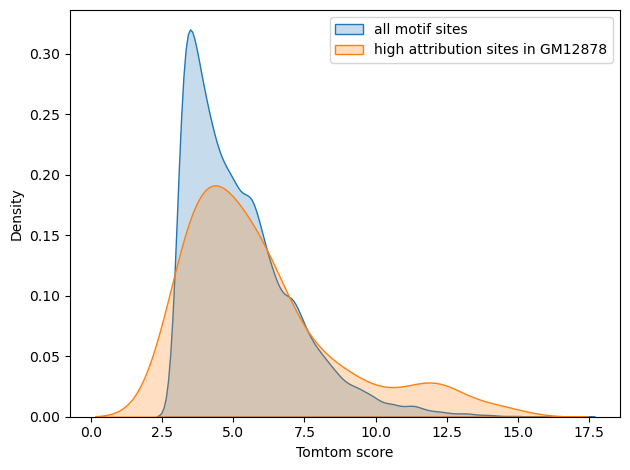

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 画密度曲线
sns.kdeplot(score_0, fill=True, bw_adjust=1.0, label='all motif sites')
sns.kdeplot(score_GM12878, fill=True, bw_adjust=1.0, label='high attribution sites in GM12878')
# sns.kdeplot(score_H1ESC, fill=True, bw_adjust=1.0, label='GM12878 high attribution sites')

plt.xlabel("Tomtom score")
plt.ylabel("Density")
plt.tight_layout()
plt.legend()
plt.show()


### 2.1 motif enrichment for high attribution

In [17]:
from scipy.stats import fisher_exact
def tail_prob_test(x0, x1, thres, option='fixed', alternative='greater'):
    if option == 'fixed':
        k0 = np.sum(x0 > thres)
        k1 = np.sum(x1 > thres)
    elif option == 'percentage':
        thres = np.quantile(x1, thres)
        k0 = np.sum(x0 > thres)
        k1 = np.sum(x1 > thres)

    n0, n1 = len(x0), len(x1)
    table = np.array([[k0, n0-k0], [k1, n1-k1]])
    stat, p = fisher_exact(table, alternative=alternative)
    # p_pool = (k0 + k1) / (n0 + n1)
    # se = np.sqrt(p_pool * (1 - p_pool) * (1/n0 + 1/n1))
    # z = (k0/n0 - k1/n1) / se
    # p = 1 - stats.norm.cdf(z) if alternative == 'greater' else stats.norm.cdf(z)
    return {
        "threshold": thres,
        "k0": k0,
        "n0": n0,
        "k1": k1,
        "n1": n1,
        "stat": stat,
        "p": p,
    }

In [18]:
def get_scores(score, motif_hits, local_background_size=10):
    score = score.sum(axis=0)
    L = score.shape[-1]
    l = None
    contribs, local_backgrounds = [], []
    for row in motif_hits.itertuples():
        s, e = int(row.start), int(row.end)
        if s < 0 or e > L or e <= s:
            continue

        if l is not None:
            assert e-s == l
        else:
            l = e-s

        contrib = score[s:e].mean()
        contribs.append(contrib)

        s = np.cumsum(score[s-local_background_size*l:e+local_background_size*l])
        local_background = (s[:-l] - s[l:])/l

        local_backgrounds.append(local_background)

    contribs = np.array(contribs)
    local_backgrounds = np.concatenate(local_backgrounds)
    return np.abs(contribs), np.abs(local_backgrounds)

In [19]:
def calc_motif_statistics(
        motif_name, 
        cells = None,
        local_background_size = 10, 
    ):
    motif_hits = all_hits[all_hits['motif_name'] == motif_name]
    if len(motif_hits) == 0:
        for motif in all_hits['motif_name'].unique():
            if motif.startswith(motif_name):
                print(f'You may look at {motif}')
        return

    if cells is None:
        cells = attrs_standardized.keys()

    statistics = {}

    for k in cells:
        contribs, local_backgrounds = get_scores(attrs_standardized[k], motif_hits, local_background_size)
        statistics[k] = tail_prob_test(contribs, local_backgrounds, thres[k], alternative='greater')
        # statistics[k] = tail_prob_test(contribs, local_backgrounds, 0.998, option='percentage', alternative='greater')

    return statistics


In [1]:
calc_motif_statistics('MSC_MA0665.1')

NameError: name 'calc_motif_statistics' is not defined

In [23]:
all_motifs = sorted(jaspar_human_hits['motif_name'].unique())
all_motifs += ['RARG_nuclearreceptor_6']
all_motifs

['ALX3_MA0634.1',
 'ARNT+HIF1A_MA0259.1',
 'ASCL1_MA1100.1',
 'ATF4_MA0833.1',
 'ATF7_MA0834.1',
 'BACH2_MA1101.1',
 'BARHL2_MA0635.1',
 'BARX1_MA0875.1',
 'BATF+JUN_MA0462.1',
 'BATF3_MA0835.1',
 'BCL6B_MA0731.1',
 'BHLHE22_MA0818.1',
 'BHLHE23_MA0817.1',
 'BHLHE40_MA0464.2',
 'BHLHE41_MA0636.1',
 'BSX_MA0876.1',
 'CDX1_MA0878.1',
 'CDX2_MA0465.1',
 'CEBPA_MA0102.3',
 'CEBPB_MA0466.2',
 'CEBPD_MA0836.1',
 'CEBPE_MA0837.1',
 'CEBPG_MA0838.1',
 'CENPB_MA0637.1',
 'CLOCK_MA0819.1',
 'CREB1_MA0018.3',
 'CREB3L1_MA0839.1',
 'CREB3_MA0638.1',
 'CTCFL_MA1102.1',
 'CTCF_MA0139.1',
 'CUX1_MA0754.1',
 'CUX2_MA0755.1',
 'DBP_MA0639.1',
 'DLX6_MA0882.1',
 'DMRT3_MA0610.1',
 'DUX4_MA0468.1',
 'DUXA_MA0884.1',
 'E2F1_MA0024.3',
 'E2F2_MA0864.1',
 'E2F3_MA0469.2',
 'E2F4_MA0470.1',
 'E2F6_MA0471.1',
 'E2F7_MA0758.1',
 'E2F8_MA0865.1',
 'EBF1_MA0154.3',
 'EGR1_MA0162.3',
 'EGR2_MA0472.2',
 'EGR3_MA0732.1',
 'EGR4_MA0733.1',
 'EHF_MA0598.2',
 'ELF1_MA0473.2',
 'ELF3_MA0640.1',
 'ELF4_MA0641.1',
 'ELF5

In [ ]:
stat = {}
for motif in all_motifs:
    stat[motif] = calc_motif_statistics(motif)

rows = []
for motif, cell_data in stat.items():
    for cell, stat in cell_data.items():
        row = {'motif_name': motif, 'cell_line': cell}
        row.update(stat)
        rows.append(row)

df = pd.DataFrame(rows)

# === 保存到本地 ===
df.to_csv(f"../result/motif_enrichment_stats_{epi}_positive.csv", index=False, sep='\t')


In [19]:
import pandas as pd

# 读取
df = pd.read_csv(f"../result/motif_enrichment_stats_{epi}_positive.csv", sep="\t")
df['k1']/df['n1']

0       0.000133
1       0.000088
2       0.000066
3       0.001249
4       0.001782
          ...   
1375    0.000186
1376    0.000183
1377    0.000304
1378    0.000411
1379    0.000380
Length: 1380, dtype: float64

In [ ]:
import pandas as pd

# 读取
df = pd.read_csv(f"../result/motif_enrichment_stats_{epi}_positive.csv", sep="\t")

# 透视：motif × cell_line 的 p 值
P = df.pivot(index="motif_name", columns="cell_line", values="p")

# 阈值
alpha_sig = 5e-2
alpha_ns  = 5e-2

specific_hits = {}
for cell in P.columns:
    cond_sig_here  = P[cell] < alpha_sig
    cond_ns_others = P.drop(columns=[cell]).gt(P[cell]).fillna(False).all(axis=1)
    mask = cond_sig_here & cond_ns_others

    result = P.loc[mask].sort_values(by=cell)
    specific_hits[cell] = result

    print(f"{cell}: {len(result)} motifs")

specific_hits


GM12878: 0 motifs
H1ESC: 0 motifs
K562: 0 motifs


{'GM12878': Empty DataFrame
 Columns: [GM12878, H1ESC, K562]
 Index: [],
 'H1ESC': Empty DataFrame
 Columns: [GM12878, H1ESC, K562]
 Index: [],
 'K562': Empty DataFrame
 Columns: [GM12878, H1ESC, K562]
 Index: []}

In [18]:
import pandas as pd

# 读取
df = pd.read_csv(f"../result/motif_enrichment_stats_{epi}_positive.csv", sep="\t")

# 选取 z 统计量列名（根据你表头自适应）
z_cols_try = ["zstat", "z_stat", "zscore", "z"]
z_col = next((c for c in z_cols_try if c in df.columns), None)
if z_col is None:
    raise ValueError(f"找不到 z 统计量列，试试把列名改成其中之一：{z_cols_try}")

# 透视：motif × cell_line 的 z 值
Z = df.pivot(index="motif_name", columns="cell_line", values=z_col)

dz = 10.0  # “显著更大”的阈值（可调）

specific_hits = {}
for cell in Z.columns:
    # 该 cell 的 z
    z_here = Z[cell]

    # 其它 cells 的最大 z（逐行）
    z_others_max = Z.drop(columns=[cell]).max(axis=1)

    # 与次优（其它 cell 中的最大）之间的差
    delta = z_here - z_others_max

    # 判定：至少比所有其它 cell 大 dz
    mask = delta >= dz

    # 整理结果：保留所有 cell 的 z，同时加一列 delta
    result = Z.loc[mask].copy()
    result["delta_vs_next_best"] = delta[mask]

    # 按当前 cell 的 z 从大到小排
    result = result.sort_values(by=cell, ascending=False)

    specific_hits[cell] = result

    print(f"{cell}: {len(result)} motifs")

specific_hits


GM12878: 85 motifs
H1ESC: 0 motifs
K562: 26 motifs


{'GM12878': cell_line           GM12878       H1ESC        K562  delta_vs_next_best
 motif_name                                                             
 ZNF384_MA1125.1  787.184785  199.445403  372.647893          414.536892
 RREB1_MA0073.1   205.760387   79.189995  122.842014           82.918373
 IRF1_MA0050.2    177.425655   31.211612   93.164993           84.260662
 ZNF740_MA0753.1  167.274586  144.093148  154.386322           12.888265
 ZSCAN4_MA1155.1  165.152094   46.685374   50.286695          114.865399
 ...                     ...         ...         ...                 ...
 NFATC3_MA0625.1   17.529219    4.027749    6.338961           11.190258
 SIX1_MA1118.1     16.336994    2.479114    6.174910           10.162084
 HOXD11_MA0908.1   15.825954    1.588412    3.368164           12.457791
 NFAT5_MA0606.1    14.925039    1.750682    4.501694           10.423345
 MEIS2_MA0774.1    14.044766    0.499291    3.482823           10.561942
 
 [85 rows x 4 columns],
 'H1ESC': Empt